### Jav-Nairobi (Temporal Equity)

### i. Libraries

In [1]:
# imports and plotting settings
import pandas as pd
import geopandas as gpd
import folium
from shapely import wkt
import gtfs_kit as gk  # already used in your code
import warnings
warnings.filterwarnings("ignore")

# optional: show more columns when printing dataframes
pd.set_option('display.max_columns', 50)

### ii. Background

Temporal equity looks at how service availability varies over time, especially during peak vs. off-peak hours, and across different regions or population groups.

The main questions:
- **1. How does transit service per 1,000 people change across hours of the day?**  
*Examines `trips_per_1k_pop_per_hour` across hours (6, 9, 15) to identify daily service patterns*

- **2. Which wards rank highest or lowest in service availability, and does this change by hour?**  
*Uses `service_rank_overall` (global ranking) and `service_rank_by_hour` (time-specific ranking) to identify consistent vs. volatile access patterns*

- **3. Do disadvantaged wards experience lower service during peak hours?**  
*Links `poverty_rate` with `service_rank_by_hour` to assess whether vulnerability correlates with reduced temporal access*

### iii. Data

#### **a. Load and Prepare Ward GeoDataFrame**

- This cell loads the processed ward-level dataset (`wards_full_gdf(with_spatial_gini).csv`) and converts its geometry column from WKT strings to Shapely geometry objects.  
It then transforms the DataFrame into a GeoDataFrame with the correct coordinate reference system (EPSG:32737) for spatial analysis.  
A quick preview confirms the shape, sample columns, and CRS.

In [2]:
# load ward dataframe that you exported earlier
ward_csv_path = '/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_gini).parquet'

ward_full_gdf = gpd.read_parquet(ward_csv_path)
print("rows, cols:", ward_full_gdf.shape)
print("sample columns:", ward_full_gdf.columns.tolist()[:10])

# Convert geometry WKT -> shapely geometry objects
# If geometry is already a geometry object, this will error — but your original code used wkt.loads so we do the same.
# ward_full_gdf['geometry'] = ward_full_gdf['geometry'].apply(wkt.loads)

# Convert to GeoDataFrame and set CRS to UTM zone used in your script (EPSG:32737)
ward_full_gdf = gpd.GeoDataFrame(ward_full_gdf, geometry='geometry', crs="EPSG:32737")

# Quick sanity print
print("CRS:", ward_full_gdf.crs)
ward_full_gdf.head(2)

rows, cols: (85, 21)
sample columns: ['gid', 'pop2009', 'county', 'subcounty', 'ward', 'uid', 'scuid', 'cuid', 'geometry', 'population']
CRS: EPSG:32737


,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry,population,constituency,poverty_rate,intersect_area,ward_area,coverage_ratio,pop_served,pct_access,pop_density,coverage_area_km2,pop_not_served,subcounty_gini
0,2044,55158.0,Nairobi,Ruaraka Sub County,Mathare North Ward,dOQTHZsuaIb,Cc8uEFkzfVf,jkG3zaihdSs,"POLYGON ((263712.094 9861509.927, 263673.142 9...",74177.992829,Ruaraka,11.1,4.096217e+05,4.635465e+05,0.883669,65548.802666,88.366913,160022.77,0.409622,8629.0,0.076869
1,2047,70641.0,Nairobi,Embakasi South Sub County,Imara Daima Ward,Nt7PPe0Vdou,aDp1odOWYC1,jkG3zaihdSs,"POLYGON ((264030.489 9855064.997, 264031.152 9...",92557.211478,Embakasi South,13.8,2.646837e+06,3.914392e+06,0.676181,62585.423418,67.618095,23645.36,2.646837,29972.0,0.268249


#### **b: Load GTFS Feed and Inspect Core Tables**

Loads the 2019 **Digital Matatus GTFS feed** using `gtfs_kit`, a toolkit for handling public transit data.  
It extracts key GTFS tables `frequencies`, `stop_times`, and `stops`  which describe route timing, stop schedules, and stop locations respectively.  
Basic summaries are printed to confirm successful loading and dataset size, followed by a quick preview of each table.


In [3]:
# Load GTFS feed using gtfs_kit and peek at frequencies, stops, stop_times
feed_path = '/home/dataopske/Desktop/jav/data/raw/digitalmatatu/GTFS_FEED_2019.zip'
feed = gk.read_feed(feed_path, dist_units='km')  # this reads the GTFS

# Important GTFS tables we will use:
frequencies = feed.frequencies.copy()
stop_times = feed.stop_times.copy()
stops_df = feed.stops.copy()

print("frequencies rows:", len(frequencies))
print("stop_times rows:", len(stop_times))
print("stops rows:", len(stops_df))

# peek
frequencies.head(2), stop_times.head(2), stops_df.head(2)


frequencies rows: 792
stop_times rows: 7533
stops rows: 4284


(    trip_id start_time  end_time  headway_secs
 0  10106110   06:00:00  09:00:00           300
 1  10106110   09:00:00  15:00:00           900,
     trip_id arrival_time departure_time  stop_id  stop_sequence
 0  10106110      6:00:00        6:00:20  0110BAA              1
 1  10106110      6:00:34        6:00:54  0110BNI              2,
    stop_id stop_name  stop_lat   stop_lon  location_type parent_station
 0  0001RLW  Railways -1.290884  36.828242              0           <NA>
 1  0002KOJ      Koja -1.281230  36.822596              1           <NA>)

In [4]:
gtfs_routes = feed.routes
gtfs_stops = feed.stops
gtfs_stop_times = feed.stop_times
gtfs_trips = feed.trips

In [5]:
# Show me what you have
print("GTFS Routes:")
print(gtfs_routes.head())
print(f"Shape: {gtfs_routes.shape}")

print("\nGTFS Stops:")
print(gtfs_stops.head())
print(f"Shape: {gtfs_stops.shape}")

print("\nGTFS Stop Times:")
print(gtfs_stop_times.head())
print(f"Shape: {gtfs_stop_times.shape}")

# Critical: Do you have route-stop sequences?
print("\nRoute 46 stops:")
route_46_trips = gtfs_trips[gtfs_trips['route_id'] == '46']
if len(route_46_trips) > 0:
    trip_id = route_46_trips.iloc[0]['trip_id']
    stops = gtfs_stop_times[gtfs_stop_times['trip_id'] == trip_id].sort_values('stop_sequence')
    print(stops[['stop_id', 'stop_sequence']])

GTFS Routes:
      route_id agency_id route_short_name                 route_long_name  \
0  10000107D11       UON             107D                     Ruaka-Ruiru   
1  10000114011       UON             114R     Ngara-Rwaka-Ndenderu-Limuru   
2  10000116011       UON              116        Koja-Ngara-Banana-Limuru   
3  10100011A11       UON              11A        Odeon-Aga Khan-Highridge   
4  10200010811       UON              108  UN-New Muthaiga-Gachie-Gichagi   

   route_type  
0           3  
1           3  
2           3  
3           3  
4           3  
Shape: (136, 5)

GTFS Stops:
   stop_id           stop_name  stop_lat   stop_lon  location_type  \
0  0001RLW            Railways -1.290884  36.828242              0   
1  0002KOJ                Koja -1.281230  36.822596              1   
2  0003NGR               Ngara -1.274395  36.823806              1   
3  0004ODN               Odeon -1.282769  36.825032              1   
4  0005AMB  Kencom/Ambassadeur -1.285963  36.8260

In [6]:
# Let's use Route 107D (Ruaka-Ruiru) as example
route_107d_trips = gtfs_trips[gtfs_trips['route_id'] == '10000107D11']
if len(route_107d_trips) > 0:
    trip_id = route_107d_trips.iloc[0]['trip_id']
    stops = gtfs_stop_times[gtfs_stop_times['trip_id'] == trip_id].sort_values('stop_sequence')
    print(f"\nRoute 107D stops ({len(stops)} stops):")
    
    # Merge with stop names
    stops_with_names = stops.merge(gtfs_stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']], on='stop_id')
    print(stops_with_names[['stop_sequence', 'stop_id', 'stop_name', 'stop_lat', 'stop_lon']].head(10))


Route 107D stops (38 stops):
   stop_sequence  stop_id            stop_name  stop_lat   stop_lon
0              1  0213MRY                Ruiru -1.147669  36.959317
1              2  0100OOA             Kwa Soko -1.149789  36.948829
2              3  0100AWA             Wataalam -1.149612  36.947408
3              4  0100TPS                 Post -1.149687  36.945525
4              5  0100OTN               Hilton -1.150637  36.942590
5              6  0110LHL   Full Gospel Church -1.151018  36.937462
6              7  0110AOH            Mama Shop -1.151753  36.931196
7              8  0110ISR        Ruiru Prisons -1.151871  36.929525
8              9  0100RJI  Ruiru Road Junction -1.152105  36.919942
9             10  0100JO.                  O.J -1.152971  36.920232


#### **c: Derive Trip Frequency per Hour**

This cell processes the GTFS `frequencies` table to estimate how often vehicles operate each hour.  
It converts the `start_time` field into time deltas to extract the hour of the day, filters out invalid or zero headways, and calculates **trips per hour** as `3600 / headway_secs`.  
Finally, it groups by `trip_id` and `hour` to obtain average trip frequencies, providing a snapshot of service intensity across hours.


In [7]:
# Convert start_time -> hour and compute trips_per_hour for each trip_id and hour
# Explanation: headway_secs is seconds between vehicles; trips/hour = 3600 / headway_secs

frequencies = frequencies.copy()
# convert start_time to timedelta safely (some GTFS might have '24:00:00' or blanks -> errors='coerce')
frequencies['start_time'] = pd.to_timedelta(frequencies['start_time'], errors='coerce')
# extract hour (0-23). NaT remain NaN
frequencies['hour'] = frequencies['start_time'].dt.seconds // 3600

# drop rows where headway_secs is missing or zero (would cause division by zero)
frequencies = frequencies[frequencies['headway_secs'].notna() & (frequencies['headway_secs'] > 0)]

# compute trips per hour
frequencies['trips_per_hour'] = 3600.0 / frequencies['headway_secs']

# if a (trip_id, hour) appears multiple times in frequencies, take the mean trips_per_hour
freq_hour = (
    frequencies
    .groupby(['trip_id', 'hour', 'headway_secs'], as_index=False)
    ['trips_per_hour']
    .mean()
)

print("freq_hour sample:")
freq_hour.head(6)

freq_hour sample:


,trip_id,hour,headway_secs,trips_per_hour
0,10106110,6,300,12.0
1,10106110,9,900,4.0
2,10106110,15,300,12.0
3,10106111,6,300,12.0
4,10106111,9,900,4.0
5,10106111,15,300,12.0


> **Understanding Headway and Trips per Hour**:
Between **6 AM and 9 AM**, the headway is **300 seconds**, meaning a bus arrives every **5 minutes**.
Since there are **3600 seconds in an hour**, we calculate the number of trips per hour as:
Trips per hour = 3600 ÷ 300 = 12
That means **12 buses per hour** operate between 6 AM and 9 AM.
Over that 3-hour period:
12 trips/hour × 3 hours = 36 trips total

So far, we computed trips per hour for each individual bus trip.  
Now, we want to **see the total number of trips running in each hour of the day**, summing across all trips.  

- We group by `hour` and sum the `trips_per_hour` values.  
- We sort the hours so the table reads logically (e.g., 6 AM → 9 AM → 3 PM).  
- We also create human-readable labels (`6 AM`, `9 AM`, `3 PM`) to make plots and tables easy to interpret. 

In [8]:
# Aggregate trips per hour across all trip_ids
agg_by_hour = freq_hour.groupby('hour', as_index=False)['trips_per_hour'].sum()  # total trips per hour
agg_by_hour = agg_by_hour.sort_values('hour')  # optional: sort by hour

# Optional: add readable labels for hours
agg_by_hour['hour_label'] = agg_by_hour['hour'].map({6:'6 AM', 9:'9 AM', 15:'3 PM'})

print("Aggregated trips per hour:")
agg_by_hour

Aggregated trips per hour:


,hour,trips_per_hour,hour_label
0,6,3168.0,6 AM
1,9,1056.0,9 AM
2,15,3168.0,3 PM



This gives us a clean **hourly snapshot of total bus service intensity** for visualization and analysis.

In [9]:
import altair as alt

# Ensure numeric type
agg_by_hour['trips_per_hour'] = agg_by_hour['trips_per_hour'].astype(float)

# Altair bar chart with a single red color
chart = alt.Chart(agg_by_hour).mark_bar(
    cornerRadiusTopLeft=3, 
    cornerRadiusTopRight=3,
    color='#d62728'  # solid red
).encode(
    x=alt.X('hour_label:N', 
            title='Hour of Day',
            sort=['6 AM', '9 AM', '3 PM']),
    y=alt.Y('trips_per_hour:Q', 
            title='Total Trips per Hour',
            scale=alt.Scale(zero=True)),
    tooltip=['hour_label', 'trips_per_hour']
).properties(
    title='Total Trips per Hour Across All Trips',
    width=400,
    height=300
)

chart

alt.Chart(...)

> Mornings and evenings have the same number of trips (3168), fewer trips during the day (1056)

#### **e. Converting Stops to Geospatial Points**

GTFS provides bus stop locations as **latitude and longitude**.  
To perform spatial analysis with wards, we need to convert these coordinates into **geospatial points** and ensure they use the **same coordinate reference system (CRS)** as the wards.  
1. Create a **GeoDataFrame** from the `stops_df` using `stop_lon` and `stop_lat`.  
   - Initial CRS is `EPSG:4326` (standard lon/lat).  
2. Transform the stops to the **wards’ CRS (`EPSG:32737`)** so that spatial operations like joins or overlays work correctly.  
3. Print the CRS and preview the first few rows to ensure the transformation worked.  

In [10]:
# Cell 5: create geopandas points from stops lat/lon and transform to ward CRS (EPSG:32737)
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df['stop_lon'], stops_df['stop_lat']),
    crs='EPSG:4326'  # GTFS stops are in lon/lat
)

# Transform stops to the same CRS as your wards so spatial join works
stops_gdf = stops_gdf.to_crs(ward_full_gdf.crs)

print("stops_gdf CRS:", stops_gdf.crs)
stops_gdf.head(3)

stops_gdf CRS: EPSG:32737


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,geometry
0,0001RLW,Railways,-1.290884,36.828242,0,<NA>,POINT (258340.426 9857215.073)
1,0002KOJ,Koja,-1.281230,36.822596,1,<NA>,POINT (257710.959 9858282.373)
2,0003NGR,Ngara,-1.274395,36.823806,1,<NA>,POINT (257845.026 9859038.513)


This prepares the stops data for any **geospatial analysis**, like counting how many stops are in each ward or mapping bus coverage.

#### **f: Mapping Trips to Stops with Hourly Frequency**

Now that we know how many trips each bus runs per hour (`trips_per_hour`), we want to **link these trips to the stops they serve**.  
 
1. We start with `stop_times` to get all **unique (trip_id, stop_id) pairs**.  
2. Merge this with `freq_hour` so each stop knows **how many trips per hour** pass through it for each trip.  
   - This creates a table where every stop served by a trip has its **hour-specific service frequency**.  
3. Print a sample to check that each stop now has `trip_id`, `hour`, and `trips_per_hour`.  


In [11]:
# Map trip -> stop and add trips_per_hour (for every hour)
trip_stops = stop_times[['trip_id', 'stop_id']].drop_duplicates()

# merge trip_stops with freq_hour to attach hour-specific trips_per_hour to each (trip_id, stop_id)
# this gives for each stop served by a trip how many trips/hr that trip provides at a given hour
stop_service = trip_stops.merge(
    freq_hour,
    on='trip_id',
    how='inner'
)

print("stop_service sample (stop_id, trip_id, hour, trips_per_hour):")
stop_service.head(6)


stop_service sample (stop_id, trip_id, hour, trips_per_hour):


,trip_id,stop_id,hour,headway_secs,trips_per_hour
0,10106110,0110BAA,6,300,12.0
1,10106110,0110BAA,9,900,4.0
2,10106110,0110BAA,15,300,12.0
3,10106110,0110BNI,6,300,12.0
4,10106110,0110BNI,9,900,4.0
5,10106110,0110BNI,15,300,12.0



> This prepares the dataset for **analyzing stop-level service intensity**, e.g., how busy each stop is at different times of day.

In GTFS, each stop has additional columns like:  
- `stop_sequence` → the order of stops in a trip  
- `arrival_time` → scheduled arrival at the stop  
- `departure_time` → scheduled departure from the stop  

For our purpose, **aggregating trips per hour per stop**, these columns are **not needed**:  

1. **Stop sequence** tells us the order stops are visited, but for **hourly frequency**, the order doesn’t matter. Each stop gets the same `trips_per_hour` for that trip.  
2. **Arrival/departure times** give exact timing, but we’re only concerned with **how many trips per hour serve each stop**, not the exact minutes.  

By omitting them, we keep the dataset **clean and focused on stop-level service intensity**, which is what we need for spatial analysis and plotting.

#### **g: Summing Service per Stop per Hour**

So far, each row in `stop_service` represents a **trip serving a stop at a specific hour**, along with that trip’s `trips_per_hour`.  

However, a single stop can be served by **multiple trips during the same hour**.  
To get the **total service intensity per stop**, we need to:  

1. Group by `stop_id` and `hour`.  
2. Sum the `trips_per_hour` values for all trips serving that stop in that hour.  

In [12]:
# Sum trips_per_hour by stop_id and hour (a stop can be served by multiple trips)
stop_hour_service = (
    stop_service
    .groupby(['stop_id', 'hour'], as_index=False)
    .agg({'trips_per_hour': 'sum'})
)

print("stop_hour_service rows:", len(stop_hour_service))
stop_hour_service.head(6)

stop_hour_service rows: 12258


,stop_id,hour,trips_per_hour
0,0001RLW,6,168.0
1,0001RLW,9,56.0
2,0001RLW,15,168.0
3,0100..M,6,12.0
4,0100..M,9,4.0
5,0100..M,15,12.0


The resulting table, `stop_hour_service`, tells us **how many bus trips per hour pass through each stop**, combining all trips.  

This is a key step before we can map or visualize **stop-level service coverage across the city**.

#### **h: Assigning Stops to Wards via Spatial Join**

We want to know **which ward each bus stop belongs to** so we can analyze service at the ward level. 

1. Reduce the `ward_full_gdf` to only the **columns we need** (`ward`, `population`, `geometry`) to keep the dataset lightweight.  
2. Perform a **spatial join** (`sjoin`) between stops and wards:  
   - Each stop point is assigned to the ward polygon it **falls within**.  
   - We use `predicate='within'` to ensure stops outside ward boundaries are excluded.  
3. The resulting `stops_with_ward` table now contains:  
   - Stop attributes (`stop_id`, coordinates, etc.)  
   - Ward name and population


In [13]:
# Spatial join to get ward for each stop point
# keep only the columns we need from ward_full_gdf to keep things small
wards_small = ward_full_gdf[['ward', 'population', 'geometry']].copy()

# perform the spatial join
stops_with_ward = gpd.sjoin(
    stops_gdf,
    wards_small,
    how='inner',
    predicate='within'  # use 'within' so stops inside ward polygon are assigned
)

# stops_with_ward now has stop attributes + ward and ward population
print("stops assigned to wards:", len(stops_with_ward))
stops_with_ward[['stop_id', 'ward', 'population']].head(6)

stops assigned to wards: 3298


,stop_id,ward,population
0,0001RLW,Nairobi Central Ward,18997.268882
1,0002KOJ,Nairobi Central Ward,18997.268882
2,0003NGR,Ngara Ward Ward,25589.814342
3,0004ODN,Nairobi Central Ward,18997.268882
4,0005AMB,Nairobi Central Ward,18997.268882
5,0006BSS,Nairobi Central Ward,18997.268882


In [14]:
stops_with_ward.columns

Index(['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type',
       'parent_station', 'geometry', 'index_right', 'ward', 'population'],
      dtype='object')


This prepares the data for **ward-level aggregation of bus service**, allowing us to analyze how service intensity varies across neighborhoods.

#### **i: Aggregating Stop-Level Service to Ward-Hour Level**

Now that each stop has been assigned to a ward and has its **hourly trips per hour**, we can summarize service at the **ward level**.  
1. **Merge `stop_hour_service`** into `stops_with_ward` so each stop now carries its `trips_per_hour` for each hour.  
2. **Aggregate to ward-hour level**:  
   - Group by `ward` and `hour`.  
   - **Sum `trips_per_hour`** across all stops in that ward to get total service intensity per hour.  
   - **Take the first `population`** value for the ward (same for all stops in that ward).  
3. The resulting `service_by_ward_hour` table tells us:  
   - **How many bus trips per hour run in each ward**, and  
   - The **ward population**, useful for per-capita analysis. 

In [15]:
# Merge stop_hour_service (which is by stop_id & hour) into stops_with_ward
stops_with_service = stops_with_ward.merge(
    stop_hour_service,
    on='stop_id',
    how='inner'   # inner keeps only stops that have service records
)

# Now aggregate up to ward-hour:
service_by_ward_hour = (
    stops_with_service
    .groupby(['ward', 'hour'], as_index=False)
    .agg({
        'trips_per_hour': 'sum',   # sum trips across all stops in that ward-hour
        'population': 'first'      # population is same for ward rows; take first
    })
)

print("ward-hour rows:", len(service_by_ward_hour))
service_by_ward_hour.head(8)

ward-hour rows: 237


,ward,hour,trips_per_hour,population
0,Airbase Ward,6,1164.0,105433.255157
1,Airbase Ward,9,388.0,105433.255157
2,Airbase Ward,15,1164.0,105433.255157
3,Babandogo,6,504.0,144280.941622
4,Babandogo,9,168.0,144280.941622
5,Babandogo,15,504.0,144280.941622
6,California Ward,6,36.0,46558.616489
7,California Ward,9,12.0,46558.616489



This table is now ready for **visualizing service intensity across wards and hours**, or calculating **trips per capita**.

> NOTE: We were exppecting `85*3=255` wards but instead got `237` rows after inner join, meaning that some stop_ids dont have `service hours`

#### **j: Normalizing Service by Population**
Different wards have different population sizes, so **raw trips per hour** can be misleading.  
A ward with more stops and more trips might appear better served, even if its population is large.  
To make service **comparable across wards**, we normalize by population:  

1. **Filter out wards with zero population** to avoid division by zero.  

2. Compute **service per 1,000 people**:  

$$
\text{service\_per\_1k\_pop} = \frac{\text{trips per hour}}{\text{population}} \times 1000
$$

3. Also compute **trips per person per hour** (a raw per-capita measure):  

$$
\text{trips\_per\_person\_per\_hour} = \frac{\text{trips per hour}}{\text{population}}
$$

In [16]:
# Normalize by population so we have comparable metric across wards
service_by_ward_hour = service_by_ward_hour.copy()
# avoid division by zero
service_by_ward_hour = service_by_ward_hour[service_by_ward_hour['population'] > 0].copy()

# Trips per hour per 1000
service_by_ward_hour['trips_per_1k_pop_per_hour'] = (
    service_by_ward_hour['trips_per_hour'] / service_by_ward_hour['population'] * 1000
)
# Trips per hour per person(capita)
service_by_ward_hour['trips_per_person_per_hour'] = (
    service_by_ward_hour['trips_per_hour'] / service_by_ward_hour['population']
)

service_by_ward_hour.head(8)

,ward,hour,trips_per_hour,population,trips_per_1k_pop_per_hour,trips_per_person_per_hour
0,Airbase Ward,6,1164.0,105433.255157,11.04016,0.01104
1,Airbase Ward,9,388.0,105433.255157,3.680053,0.00368
2,Airbase Ward,15,1164.0,105433.255157,11.04016,0.01104
3,Babandogo,6,504.0,144280.941622,3.493185,0.003493
4,Babandogo,9,168.0,144280.941622,1.164395,0.001164
5,Babandogo,15,504.0,144280.941622,3.493185,0.003493
6,California Ward,6,36.0,46558.616489,0.773219,0.000773
7,California Ward,9,12.0,46558.616489,0.25774,0.000258


**Interpreting Population-Normalized Service**

This table shows **bus service intensity per ward and hour**, both in raw and population-adjusted terms:

- **trips_per_hour** → total bus trips passing through the ward during that hour.  
  - Example: At 6 AM, Airbase Ward has 1164 trips in total.  

- **population** → number of people living in the ward.  

- **trips_per_1k_pop_per_hour** → trips per 1,000 people per hour.  
  - Example: 11.04 means for every 1,000 residents, there are ~11 trips per hour.  

- **trips_per_person_per_hour** → trips per individual per hour (raw per-capita).  
  - Example: 0.011 means each person, on average, has 0.011 trips per hour — same as 11 trips per 1,000 people, just scaled differently.  

**Key idea:** Population-normalized metrics let us **fairly compare service across wards**, regardless of population size.


#### **k. Sanity Check: Inspect Service at a Specific Hour**

Before creating plots or performing deeper analysis, we **inspect the data for a single hour**.  
1. We pick an hour of interest (`hour_to_inspect = 9`, i.e., 9 AM).  
2. Filter `service_by_ward_hour` to include only rows for that hour.  
3. Sort wards by **trips per 1,000 people per hour** (`trips_per_1k_pop_per_hour`) in descending order.  
4. Display the **top 8 wards**, showing:  
   - `ward` name  
   - `trips_per_hour` (raw total trips)  
   - `population`  
   - `trips_per_1k_pop_per_hour` (population-normalized service)  

In [17]:
# Cell 11: sanity checks - pick an hour you care about (e.g., 8 for 8 AM)
hour_to_inspect = 15

subset = service_by_ward_hour[service_by_ward_hour['hour'] == hour_to_inspect].copy()
subset = subset.sort_values('trips_per_1k_pop_per_hour', ascending=False).reset_index(drop=True)

print(f"Top 8 wards by rips_per_1k_pop_per_hour at hour {hour_to_inspect}:")
subset[['ward', 'trips_per_hour', 'population', 'trips_per_1k_pop_per_hour']].head(8)


Top 8 wards by rips_per_1k_pop_per_hour at hour 15:


,ward,trips_per_hour,population,trips_per_1k_pop_per_hour
0,Nairobi Central Ward,3624.0,18997.268882,190.764263
1,Kayole South Ward,792.0,8232.274748,96.206702
2,Ngara Ward Ward,2064.0,25589.814342,80.657092
3,Makongeni Ward,1548.0,27239.297781,56.829659
4,Parklands/highridge Ward,2832.0,69612.843253,40.682148
5,Kileleshwa Ward,2964.0,81906.408407,36.187645
6,Nairobi South Ward,2028.0,56437.636574,35.933468
7,Pipeline Ward,1380.0,40062.523436,34.446158


- This helps us **verify that the data looks reasonable**, check for any outliers, and see which wards are **best or worst served** at a specific time of day.

In [18]:
import altair as alt
import pandas as pd

hours_of_interest = [6, 9, 15]

# Prepare top 5 and bottom 5 for each hour separately
top_list = []
bottom_list = []

for h in hours_of_interest:
    subset = service_by_ward_hour[service_by_ward_hour['hour'] == h].copy()
    subset = subset.sort_values('trips_per_1k_pop_per_hour', ascending=False)
    
    # top 5
    top = subset.head(5).copy()
    top['rank_type'] = 'Top 5'
    top['hour_label'] = f'{h} AM' if h < 12 else f'{h-12 if h>12 else h} PM'
    top_list.append(top)
    
    # bottom 5
    bottom = subset.tail(5).copy()
    bottom['rank_type'] = 'Bottom 5'
    bottom['hour_label'] = f'{h} AM' if h < 12 else f'{h-12 if h>12 else h} PM'
    bottom_list.append(bottom)

top_data = pd.concat(top_list, ignore_index=True)
bottom_data = pd.concat(bottom_list, ignore_index=True)

# Ensure ward names are strings
top_data['ward'] = top_data['ward'].astype(str)
bottom_data['ward'] = bottom_data['ward'].astype(str)

# Define hour order for columns
hour_label_order = ['6 AM', '9 AM', '3 PM']

# Custom color palette for discrete hours
hour_colors = ['#d62728', '#ff7f0e', '#2ca02c']  # red, orange, green

# Top 5 chart
top_chart = alt.Chart(top_data).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('ward:N', sort=None, title='Ward'),
    y=alt.Y('trips_per_1k_pop_per_hour:Q', title='Trips per 1,000 People', scale=alt.Scale(zero=True)),
    color=alt.Color('hour_label:N', title='Hour', scale=alt.Scale(domain=hour_label_order, range=hour_colors)),
    column=alt.Column('hour_label:N', header=alt.Header(labelAngle=0), sort=hour_label_order),
    tooltip=['ward', 'trips_per_hour', 'population', 'trips_per_1k_pop_per_hour']
).properties(
    width=200,
    height=250,
    title='Top 5 Wards by Population-Normalized Bus Service'
)

# Bottom 5 chart
bottom_chart = alt.Chart(bottom_data).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('ward:N', sort=None, title='Ward'),
    y=alt.Y('trips_per_1k_pop_per_hour:Q', title='Trips per 1,000 People', scale=alt.Scale(zero=True)),
    color=alt.Color('hour_label:N', title='Hour', scale=alt.Scale(domain=hour_label_order, range=hour_colors)),
    column=alt.Column('hour_label:N', header=alt.Header(labelAngle=0), sort=hour_label_order),
    tooltip=['ward', 'trips_per_hour', 'population', 'trips_per_1k_pop_per_hour']
).properties(
    width=200,
    height=250,
    title='Bottom 5 Wards by Population-Normalized Bus Service'
)

# Combine top and bottom vertically
final_chart = alt.vconcat(top_chart, bottom_chart)
final_chart


alt.VConcatChart(...)

- **Best served wards:** Nairobi Central, Kayole South, Ngara, Makongeni, and Parklands/Highridge consistently have high **trips per hour per 1,000 people** across **6 AM, 9 AM, and 3 PM**.  
- **Least served wards:** Kahawa, Korogocho, California, Eastleigh South, and Mathare North have the lowest **trips per hour per person**.

#### **l. Merge Hourly Service into Wards for Mapping**

- We select an **hour of interest** (`hour_to_map`) to visualize, e.g., 9 AM.  
- Extract the relevant metrics: **`trips_per_1k_pop_per_hour`** and **`trips_per_hour`** for each ward at that hour.  
- Merge these metrics into the **full wards GeoDataFrame** (`ward_full_gdf`) to attach spatial geometry.  
- Wards with **no service data** are filled with `0` to avoid missing values.  
- Convert the CRS to **WGS84 (EPSG:4326)** so the data can be used directly in **Folium maps**, which require latitude/longitude coordinates.


In [19]:
# Cell 12: merge hourly service back into wards GeoDataFrame so we can map
# choose hour_to_map (change this to create different maps for other hours)
hour_to_map = 6

hour_df = service_by_ward_hour[service_by_ward_hour['hour'] == hour_to_map][['ward','trips_per_1k_pop_per_hour', 'trips_per_hour']]

# merge into ward_full_gdf (wards already in EPSG:32737)
wards_for_map = ward_full_gdf.merge(hour_df, on='ward', how='left')

# fill NaN service with 0 (wards with no mapped stops/trips)
wards_for_map['trips_per_1k_pop_per_hour'] = wards_for_map['trips_per_1k_pop_per_hour'].fillna(0)
wards_for_map['trips_per_hour'] = wards_for_map['trips_per_hour'].fillna(0)

# convert to WGS84 for Folium display (Folium expects lat/lon)
wards_for_map_wgs = wards_for_map.to_crs(epsg=4326)

wards_for_map_wgs[['ward','population','trips_per_hour','trips_per_1k_pop_per_hour']].head(6)

,ward,population,trips_per_hour,trips_per_1k_pop_per_hour
0,Mathare North Ward,74177.992829,12.0,0.161773
1,Imara Daima Ward,92557.211478,528.0,5.70458
2,Parklands/highridge Ward,69612.843253,2832.0,40.682148
3,Kilimani Ward,142658.597296,3804.0,26.66506
4,Kileleshwa Ward,81906.408407,2964.0,36.187645
5,Woodley/kenyatta Golf Course Ward,185176.167977,1944.0,10.498111


#### **j. Folium Map of Ward-Level Bus Service**

- Center the map on the **mean centroid** of all wards.  
- Use **CartoDB Positron tiles** for a clean base map.  
- Add a **GeoJSON layer** for wards, with a **style function** that colors wards by `trips_per_1k_pop_per_hour`:
  - `0` → light gray (`#f2f2f2`)  
  - `<1` → very light red (`#fee5d9`)  
  - `<3` → light red (`#fcae91`)  
  - `<6` → medium red (`#fb6a4a`)  
  - `>=6` → dark red (`#cb181d`)  
- Tooltips show **ward name, population, total trips/hour, and trips per 1k people** on hover.  
- Add **layer controls** so additional layers can be toggled if needed.


In [20]:
# Cell 13: Folium map centered on mean centroid of wards
m_center = wards_for_map_wgs.unary_union.centroid.coords[:][0][::-1]  # (lat, lon)
m = folium.Map(location=m_center, zoom_start=11, tiles='cartodbpositron')

# Create a style function based on service level (simple linear scaling)
def style_func(feature):
    val = feature['properties']['trips_per_1k_pop_per_hour'] or 0
    # simple buckets: you can change breakpoints later
    if val == 0:
        fill = '#f2f2f2'
    elif val < 1:
        fill = '#fee5d9'
    elif val < 3:
        fill = '#fcae91'
    elif val < 6:
        fill = '#fb6a4a'
    else:
        fill = '#cb181d'
    return {
        'fillColor': fill,
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7
    }

# create tooltip fields for hover (these show on hover)
tooltip = folium.GeoJsonTooltip(
    fields=['ward', 'population', 'trips_per_hour', 'trips_per_1k_pop_per_hour'],
    aliases=['Ward', 'Population', 'Trips/hour (sum)', 'Trips per 1k pop'],
    localize=True
)

gj = folium.GeoJson(
    wards_for_map_wgs,
    name=f"Service per 1k pop per hour at {hour_to_map}:00",
    style_function=style_func,
    tooltip=tooltip
).add_to(m)

# Add a color scale legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 200px; height: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<p style="margin-top:0; font-weight:bold;">Trips per 1k Population</p>
<p style="margin:5px 0;"><i style="background:#cb181d; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> ≥ 6</p>
<p style="margin:5px 0;"><i style="background:#fb6a4a; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> 3 - 6</p>
<p style="margin:5px 0;"><i style="background:#fcae91; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> 1 - 3</p>
<p style="margin:5px 0;"><i style="background:#fee5d9; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> < 1</p>
<p style="margin:5px 0;"><i style="background:#f2f2f2; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7; border:1px solid #999;"></i> 0</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)

# display the map (in Jupyter this will render)
m

Added a slider for 6, 9 and 15 hours

In [21]:
import ipywidgets as widgets
from IPython.display import display

# Cell 12: Create interactive map with hour slider
def create_map_for_hour(hour_to_map):
    """Generate a Folium map for a specific hour"""
    # Merge hourly service data
    hour_df = service_by_ward_hour[service_by_ward_hour['hour'] == hour_to_map][['ward','trips_per_1k_pop_per_hour', 'trips_per_hour']]
    wards_for_map = ward_full_gdf.merge(hour_df, on='ward', how='left')
    
    # Fill NaN service with 0
    wards_for_map['trips_per_1k_pop_per_hour'] = wards_for_map['trips_per_1k_pop_per_hour'].fillna(0)
    wards_for_map['trips_per_hour'] = wards_for_map['trips_per_hour'].fillna(0)
    
    # Convert to WGS84 for Folium
    wards_for_map_wgs = wards_for_map.to_crs(epsg=4326)
    
    # Create map
    m_center = wards_for_map_wgs.unary_union.centroid.coords[:][0][::-1]
    m = folium.Map(location=m_center, zoom_start=11, tiles='cartodbpositron')
    
    # Style function
    def style_func(feature):
        val = feature['properties']['trips_per_1k_pop_per_hour'] or 0
        if val == 0:
            fill = '#f2f2f2'
        elif val < 1:
            fill = '#fee5d9'
        elif val < 3:
            fill = '#fcae91'
        elif val < 6:
            fill = '#fb6a4a'
        else:
            fill = '#cb181d'
        return {
            'fillColor': fill,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        }
    
    # Tooltip
    tooltip = folium.GeoJsonTooltip(
        fields=['ward', 'population', 'trips_per_hour', 'trips_per_1k_pop_per_hour'],
        aliases=['Ward', 'Population', 'Trips/hour (sum)', 'Trips per 1k pop'],
        localize=True
    )
    
    # Add GeoJson layer
    folium.GeoJson(
        wards_for_map_wgs,
        name=f"trips_per_1k_pop_per_hour {hour_to_map}:00",
        style_function=style_func,
        tooltip=tooltip
    ).add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: 180px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <p style="margin-top:0; font-weight:bold;">Trips per 1k Population</p>
    <p style="margin:5px 0;"><i style="background:#cb181d; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> ≥ 6</p>
    <p style="margin:5px 0;"><i style="background:#fb6a4a; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> 3 - 6</p>
    <p style="margin:5px 0;"><i style="background:#fcae91; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> 1 - 3</p>
    <p style="margin:5px 0;"><i style="background:#fee5d9; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7;"></i> < 1</p>
    <p style="margin:5px 0;"><i style="background:#f2f2f2; width:20px; height:20px; float:left; margin-right:8px; opacity:0.7; border:1px solid #999;"></i> 0</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    folium.LayerControl().add_to(m)
    
    return m

# Create interactive slider
hour_slider = widgets.SelectionSlider(
    options=[('6 AM', 6), ('9 AM', 9), ('3 PM', 15)],
    value=6,
    description='Hour:',
    continuous_update=False,  # Only update when slider is released
    orientation='horizontal',
    readout=True
)

# Create output widget for the map
output = widgets.Output()

def update_map(change):
    with output:
        output.clear_output(wait=True)
        m = create_map_for_hour(change['new'])
        display(m)

# Attach the update function to slider
hour_slider.observe(update_map, names='value')

# Display slider and initial map
display(hour_slider)
with output:
    m = create_map_for_hour(6)
    display(m)
display(output)

SelectionSlider(continuous_update=False, description='Hour:', options=(('6 AM', 6), ('9 AM', 9), ('3 PM', 15))…

Output()

#### **k. Gini Coefficient Function**
- This function calculates the **Gini coefficient**, a measure of **inequality** in a distribution.  
- Input: a 1D array of **non-negative values** (e.g., service per ward, income, trips).  
- Output: a single number between **0 and 1**:  
  - `0` → perfect equality (all values are the same)  
  - `1` → maximum inequality (all value concentrated in one element)  
- **Steps inside the function:**  
  1. Convert input to a NumPy array and remove any negative values.  
  2. Sort the array in ascending order.  
  3. Apply the standard formula:  

$$
G = \frac{2 \sum_{i=1}^{n} i \cdot x_i}{n \sum_{i=1}^{n} x_i} - \frac{n+1}{n}
$$

  - Returns `np.nan` if the array is empty.

In [22]:
import numpy as np

def gini(array):
    """
    Calculate the Gini coefficient of a numpy array.
    Formula reference:
        G = (2 * Σ(i * xi)) / (n * Σxi) - (n + 1) / n
    """
    array = np.array(array)
    array = array[array >= 0]  # remove negatives if any
    if len(array) == 0:
        return np.nan
    
    sorted_array = np.sort(array)
    n = len(sorted_array)
    index = np.arange(1, n + 1)
    
    return (2 * np.sum(index * sorted_array) / (n * np.sum(sorted_array))) - ((n + 1) / n)


**Gini Coefficient for Bus Service Access**

- We compute the **Gini coefficient** on `trips_per_1k_pop_per_hour` across all wards to measure **inequality in bus service access**.  
- Each ward contributes its **population-normalized trips per hour**.  
- The formula sorts the values, weighs them by rank, and calculates how unevenly the service is distributed:  
  - `0` → perfect equality (all wards get the same service per 1k people)  
  - `1` → maximum inequality (all service concentrated in a single ward)  
- The result here, **0.610**, indicates **moderate to high inequality**, meaning some wards have much better access than others.


##### **1. Hourly Gini**
Captures both differences between wards and differences across hours.Shows inequality throughout the day, so it’s sensitive to peak vs off-peak service. Useful if you care about how service is distributed in real time.

In [23]:
# Gini for service_per_1k_pop across wards
hourly_gini = gini(service_by_ward_hour['trips_per_1k_pop_per_hour'])
print(f"Hourly Gini for service access = {hourly_gini:.3f}")


Hourly Gini for service access = 0.610


**Intepretation: Hourly Gini (0.610)**  
- Computed across **all ward-hour combinations** (6 AM, 9 AM, 3 PM for each ward).  
- Captures both:  
  - Differences **between wards** (some wards get more trips per 1,000 people than others).  
  - Differences **within wards across hours** (service peaks vs off-peak).  
- Interpretation: **moderate to high inequality**, meaning some wards are much better served than others throughout the day, especially during peak hours.

##### **2: Daily Gini**
Computed after averaging each ward’s service across hours:Captures only differences between wards, ignoring hourly variation. Shows inequality on a “typical day” basis. Useful if you care about overall equity in service access per ward, regardless of time of day.

In [24]:
avg_service_per_ward = service_by_ward_hour.groupby('ward')['trips_per_1k_pop_per_hour'].mean()
gini_daily = gini(avg_service_per_ward)
print(f"Daily Gini for service access = {gini_daily:.3f}")

Daily Gini for service access = 0.573


##### **3. Lorenz curve**

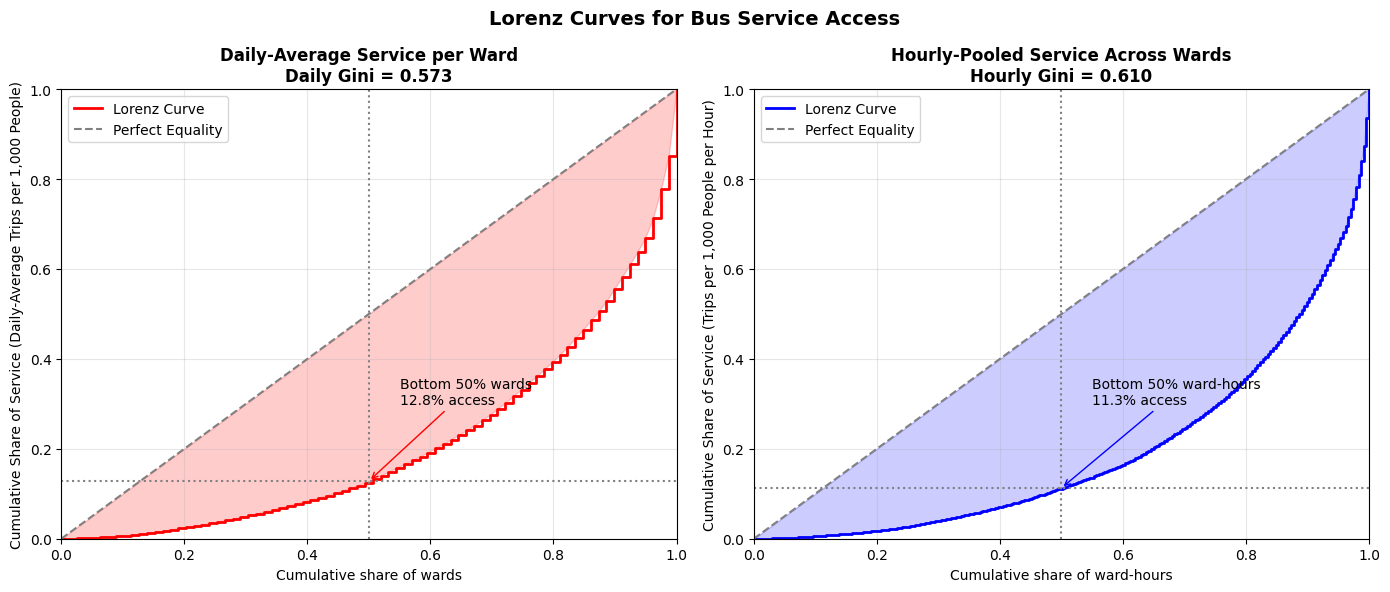

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Daily-average Lorenz curve
# -----------------------
x_daily = np.sort(avg_service_per_ward.values)
n_daily = len(x_daily)
cum_service_daily = np.cumsum(x_daily) / x_daily.sum()
cum_service_daily = np.insert(cum_service_daily, 0, 0)
equal_line_daily = np.linspace(0, 1, n_daily + 1)
bottom50_daily = np.interp(0.5, np.linspace(0,1,n_daily+1), cum_service_daily)

# -----------------------
# Hourly-pooled Lorenz curve
# -----------------------
x_hourly = np.sort(service_by_ward_hour['trips_per_1k_pop_per_hour'].dropna().values)
n_hourly = len(x_hourly)
cum_service_hourly = np.cumsum(x_hourly) / x_hourly.sum()
cum_service_hourly = np.insert(cum_service_hourly, 0, 0)
equal_line_hourly = np.linspace(0, 1, n_hourly + 1)
bottom50_hourly = np.interp(0.5, np.linspace(0,1,n_hourly+1), cum_service_hourly)

# -----------------------
# Plot side-by-side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Daily
axes[0].plot(equal_line_daily, cum_service_daily, drawstyle='steps-post', color='red', linewidth=2, label='Lorenz Curve')
axes[0].plot(equal_line_daily, equal_line_daily, '--', color='gray', label='Perfect Equality')
axes[0].axvline(0.5, linestyle=':', color='gray')
axes[0].axhline(bottom50_daily, linestyle=':', color='gray')
axes[0].annotate(f'Bottom 50% wards\n{bottom50_daily:.1%} access', xy=(0.5, bottom50_daily),
                 xytext=(0.55, 0.3), arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
axes[0].fill_between(equal_line_daily, cum_service_daily, equal_line_daily, color='red', alpha=0.2)
axes[0].set_title(f'Daily-Average Service per Ward\nDaily Gini = {gini_daily:.3f}', fontweight='bold')
axes[0].set_xlabel('Cumulative share of wards')
axes[0].set_ylabel('Cumulative Share of Service (Daily-Average Trips per 1,000 People)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Hourly
axes[1].plot(equal_line_hourly, cum_service_hourly, drawstyle='steps-post', color='blue', linewidth=2, label='Lorenz Curve')
axes[1].plot(equal_line_hourly, equal_line_hourly, '--', color='gray', label='Perfect Equality')
axes[1].axvline(0.5, linestyle=':', color='gray')
axes[1].axhline(bottom50_hourly, linestyle=':', color='gray')
axes[1].annotate(f'Bottom 50% ward-hours\n{bottom50_hourly:.1%} access', xy=(0.5, bottom50_hourly),
                 xytext=(0.55, 0.3), arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10)
axes[1].fill_between(equal_line_hourly, cum_service_hourly, equal_line_hourly, color='blue', alpha=0.2)
axes[1].set_title(f'Hourly-Pooled Service Across Wards\nHourly Gini = {hourly_gini:.3f}', fontweight='bold')
axes[1].set_xlabel('Cumulative share of ward-hours')
axes[1].set_ylabel('Cumulative Share of Service (Trips per 1,000 People per Hour)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Lorenz Curves for Bus Service Access', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/home/dataopske/Desktop/jav/data/training_output/lorenz_curve_temporal.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation: Daily-Average Gini (0.573)**  
- First averaged each ward’s service across the day, then computed Gini.  
- Captures **inequality between wards only**, ignoring time-of-day variation.  
- Interpretation: inequality is slightly lower than the overall Gini, suggesting that **peak/off-peak differences contribute somewhat to overall service inequality**, but some wards consistently receive more service than others.

**Takeaway:**  
- Hourly Gini highlights **temporal and spatial disparities**, while daily-average Gini focuses on **ward-level equity**. Reporting both gives a fuller picture of service distribution.

##### **4. Hourly Transit Service Inequality (Gini Index)**

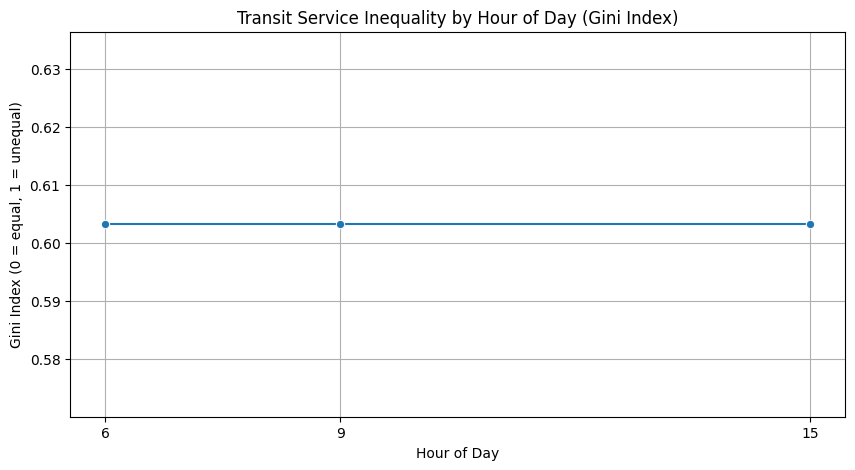

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# gini_by_hour is computed from service_by_ward_hour
gini_by_hour = (
    service_by_ward_hour.groupby('hour')['trips_per_1k_pop_per_hour']
    .apply(lambda x: gini(x))
    .reset_index(name='gini_index')
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=gini_by_hour, x='hour', y='gini_index', marker='o')
plt.title('Transit Service Inequality by Hour of Day (Gini Index)')
plt.xlabel('Hour of Day')
plt.ylabel('Gini Index (0 = equal, 1 = unequal)')
plt.xticks([6, 9, 15])  # optional: highlight the hours you care about
plt.grid(True)
plt.savefig("/home/dataopske/Desktop/jav/data/training_output/service_inequality_by_hour_of_day.png", dpi=300, bbox_inches="tight")
plt.show()

The Gini index across hours (6 AM, 9 AM, 3 PM) is steady at ~0.57.

This indicates that the inequality in transit service across wards does not change much during the day:

- Wards that are well-served in the morning remain well-served later, and poorly served wards remain underserved.
- Although the absolute number of trips per hour changes, the relative distribution between wards stays roughly the same, which is why the Gini index remains constant.

In short, the pattern of unequal service is persistent throughout the day, not just at one hour.


#### **l: Handling Missing Wards in Service Data**

**i. Check for wards with missing data**

Some wards in the master ward list do not appear in the `service_by_ward_hour` dataset.  
This step identifies which wards are missing so we can handle them appropriately (e.g., assign zero service or investigate data gaps).


In [27]:
all_wards = set(ward_full_gdf['ward'])
wards_in_data = set(service_by_ward_hour['ward'])
missing_wards = all_wards - wards_in_data
print(missing_wards)

{'Laini Saba Ward', 'Huruma Ward', 'Lindi Ward', 'Kwa Reuben Ward', 'Kware Ward', 'Dandora Area Iv Ward'}


- We shall impute the missing wards with zero. Zero-filling is appropriate here because missing data genuinely means "no transit service at that time" it's not missing data, it's zero service.

**ii. Completing the Ward × Hour Grid**

To ensure all wards and hours are represented, we create a complete **ward × hour** grid:

1. Generate all combinations of wards and hours.
2. Merge with population data so we can normalize service per capita.
3. Merge existing transit service data (`trips_per_hour`, `service_per_1k_pop`).
4. Fill missing service values with 0 - missing data here genuinely means **no service**.
5. Replace the old `service_by_ward_hour` with this complete dataset for downstream analysis.

In [28]:
# Step 1: Create a complete ward × hour grid
wards = ward_full_gdf['ward'].unique()
hours = service_by_ward_hour['hour'].unique()  # Use all hours from data, not just [6,9,15]

full_index = pd.MultiIndex.from_product([wards, hours], names=['ward', 'hour'])
full_df = pd.DataFrame(index=full_index).reset_index()

# Step 2: Merge with population data (needed for normalization)
ward_pop = ward_full_gdf[['ward', 'population']].drop_duplicates()
full_df = full_df.merge(ward_pop, on='ward', how='left')

# Step 3: Merge your existing service data
service_complete = full_df.merge(
    service_by_ward_hour[['ward', 'hour', 'trips_per_hour', 'trips_per_1k_pop_per_hour']],
    on=['ward', 'hour'],
    how='left'
)

# Step 4: Fill missing values with 0 (no service = 0 trips)
service_complete['trips_per_hour'] = service_complete['trips_per_hour'].fillna(0)
service_complete['trips_per_1k_pop_per_hour'] = service_complete['trips_per_1k_pop_per_hour'].fillna(0)

# Step 5: Use service_complete instead of service_by_ward_hour going forward
service_by_ward_hour = service_complete.copy()

In [29]:
service_by_ward_hour.isna().sum()

ward                         0
hour                         0
population                   0
trips_per_hour               0
trips_per_1k_pop_per_hour    0
dtype: int64

This guarantees that every ward-hour combination is accounted for, making subsequent summaries and visualizations consistent.

#### **m: Ward Ranking by Transit Service Access**

To further understand inequality patterns across space and time, we assign **two types of ranks** to each ward based on their service level (`trips_per_1k_pop_per_hour`):

1. **Overall Rank (`service_rank_overall`)**  
   - Computed across *all ward-hour combinations* (6 AM → 3 PM).  
   - Reflects a ward’s relative position citywide, combining all time periods.  
   - The `method='min'` ensures tied values receive the same rank, while subsequent ranks skip ahead (e.g., 1, 2, 2, 4).  
   - Range ≈ **1–255**, depending on total wards.

2. **Hourly Rank (`service_rank_by_hour`)**  
   - Computed **within each hour**, allowing comparison between wards during the same time window.  
   - This helps reveal temporal shifts — for example, a ward that ranks low in the morning might improve by afternoon.

Together, these dual rankings distinguish **spatial disparities (overall inequality)** from **temporal fluctuations (hourly inequality)** in transit service distribution across Nairobi’s wards.

In [30]:
# Attach average service and gini
ward_gini_gdf = ward_full_gdf.merge(
    service_by_ward_hour.drop(columns=['population']),
    on='ward',
    how='left'
)

# Overall rank (1-255): rank ALL ward-hour combinations globally
# method='min' means ties push next rank down (e.g., 1, 2, 2, 4, 5...)
ward_gini_gdf['service_rank_overall'] = ward_gini_gdf['trips_per_1k_pop_per_hour'].rank(ascending=False, method='min').astype(int)

# Hourly rank (1-n per hour): rank within each hour separately
ward_gini_gdf['service_rank_by_hour'] = ward_gini_gdf.groupby('hour')['trips_per_1k_pop_per_hour'] \
                                                     .rank(ascending=False, method='min').astype(int)

# Inspect
ward_gini_gdf[['ward', 'hour', 'trips_per_1k_pop_per_hour', 'service_rank_overall', 'service_rank_by_hour']].head(12)

,ward,hour,trips_per_1k_pop_per_hour,service_rank_overall,service_rank_by_hour
0,Mathare North Ward,6,0.161773,235,79
1,Mathare North Ward,9,0.053924,237,79
2,Mathare North Ward,15,0.161773,235,79
3,Imara Daima Ward,6,5.70458,123,50
4,Imara Daima Ward,9,1.901527,192,50
5,Imara Daima Ward,15,5.70458,123,50
6,Parklands/highridge Ward,6,40.682148,10,5
7,Parklands/highridge Ward,9,13.560716,59,5
8,Parklands/highridge Ward,15,40.682148,10,5
9,Kilimani Ward,6,26.66506,24,11


In [31]:
ward_gini_gdf.head()

,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry,population,constituency,poverty_rate,intersect_area,ward_area,coverage_ratio,pop_served,pct_access,pop_density,coverage_area_km2,pop_not_served,subcounty_gini,hour,trips_per_hour,trips_per_1k_pop_per_hour,service_rank_overall,service_rank_by_hour
0,2044,55158.0,Nairobi,Ruaraka Sub County,Mathare North Ward,dOQTHZsuaIb,Cc8uEFkzfVf,jkG3zaihdSs,"POLYGON ((263712.094 9861509.927, 263673.142 9...",74177.992829,Ruaraka,11.1,4.096217e+05,4.635465e+05,0.883669,65548.802666,88.366913,160022.77,0.409622,8629.0,0.076869,6,12.0,0.161773,235,79
1,2044,55158.0,Nairobi,Ruaraka Sub County,Mathare North Ward,dOQTHZsuaIb,Cc8uEFkzfVf,jkG3zaihdSs,"POLYGON ((263712.094 9861509.927, 263673.142 9...",74177.992829,Ruaraka,11.1,4.096217e+05,4.635465e+05,0.883669,65548.802666,88.366913,160022.77,0.409622,8629.0,0.076869,9,4.0,0.053924,237,79
2,2044,55158.0,Nairobi,Ruaraka Sub County,Mathare North Ward,dOQTHZsuaIb,Cc8uEFkzfVf,jkG3zaihdSs,"POLYGON ((263712.094 9861509.927, 263673.142 9...",74177.992829,Ruaraka,11.1,4.096217e+05,4.635465e+05,0.883669,65548.802666,88.366913,160022.77,0.409622,8629.0,0.076869,15,12.0,0.161773,235,79
3,2047,70641.0,Nairobi,Embakasi South Sub County,Imara Daima Ward,Nt7PPe0Vdou,aDp1odOWYC1,jkG3zaihdSs,"POLYGON ((264030.489 9855064.997, 264031.152 9...",92557.211478,Embakasi South,13.8,2.646837e+06,3.914392e+06,0.676181,62585.423418,67.618095,23645.36,2.646837,29972.0,0.268249,6,528.0,5.70458,123,50
4,2047,70641.0,Nairobi,Embakasi South Sub County,Imara Daima Ward,Nt7PPe0Vdou,aDp1odOWYC1,jkG3zaihdSs,"POLYGON ((264030.489 9855064.997, 264031.152 9...",92557.211478,Embakasi South,13.8,2.646837e+06,3.914392e+06,0.676181,62585.423418,67.618095,23645.36,2.646837,29972.0,0.268249,9,176.0,1.901527,192,50


In [32]:
ward_gini_gdf.columns

Index(['gid', 'pop2009', 'county', 'subcounty', 'ward', 'uid', 'scuid', 'cuid',
       'geometry', 'population', 'constituency', 'poverty_rate',
       'intersect_area', 'ward_area', 'coverage_ratio', 'pop_served',
       'pct_access', 'pop_density', 'coverage_area_km2', 'pop_not_served',
       'subcounty_gini', 'hour', 'trips_per_hour', 'trips_per_1k_pop_per_hour',
       'service_rank_overall', 'service_rank_by_hour'],
      dtype='object')

In [33]:
# Export as parquet file
ward_gini_gdf.to_parquet('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_temporal_gini).parquet', index=False)

### iv. Summary of Temporal Columns and Their Downstream Role

In the final dataset, several columns capture **temporal dynamics** of transit service access - crucial for understanding **when** disparities occur, not just **where**.  
These are:

- **`hour`** → Represents the specific time window (e.g., 6, 9, 15 hours) during which service data was aggregated.  
  It enables temporal slicing of the dataset — letting us analyze how access patterns evolve through the day.

- **`trips_per_hour`** → Raw measure of total trips departing or serving a ward at a given hour.  
  This is the foundation for all hourly analyses, directly reflecting network activity intensity.

- **`trips_per_1k_pop_per_hour`** → Normalized measure of service intensity, controlling for population differences.  
  It converts absolute service counts into *per-capita* terms, allowing fairer comparisons between wards of varying population size.

- **`service_rank_overall`** → Cross-temporal rank that compares all ward-hour combinations citywide.  
  It provides a **global perspective** of inequality - showing which wards consistently enjoy higher service levels throughout the day.

- **`service_rank_by_hour`** → Within-hour rank that captures **temporal variability** in accessibility.  
  It allows tracking how a ward’s relative position changes from morning to afternoon — revealing time-specific inequities.

### v. Downstream Utility

These temporal attributes collectively enable:
1. **Temporal Gini Analysis** — Measuring how inequality in service access fluctuates by hour.  
2. **Dynamic Mapping** — Creating hour-specific service maps (e.g., at 6 AM, 9 AM, 3 PM) to visualize changing accessibility.  
3. **Ranking Dynamics** — Comparing static (overall) versus dynamic (hourly) rankings to identify wards that are persistently underserved or only disadvantaged at certain times.  
4. **Equity Monitoring Dashboards** — Feeding into visual dashboards or policy reports where both *when* and *where* matter.

In essence, these temporal fields transition the analysis from a **static snapshot** to a **spatiotemporal understanding** of Nairobi’s transit accessibility — crucial for evidence-based urban mobility planning.
